<a href="https://colab.research.google.com/github/Najaf-Ali12/Complete-NLP-Projects/blob/main/Customer_Query_Categorizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Importing necessary libraries
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
import wandb  # for curve visualization


In [24]:
# Loading dataset
dataset=load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset",split="train")
data=dataset.to_pandas()

In [25]:
data.columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [26]:
# Checking for duplicates and null values
data.duplicated().sum()
data.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


In [27]:
# Removing unwanted columns
data=data.drop(["flags","intent","response"],axis=1)
data.columns

Index(['instruction', 'category'], dtype='object')

In [28]:
# Checking for data imbalancing
data['category'].value_counts()

,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


In [29]:
# Creating mapping between the labels and their names
unique_categories = sorted(balanced_data['category'].unique().tolist())
label2id={label:id for id,label in enumerate(unique_categories)}
id2label={id:label for label,id in label2id.items()}


In [30]:
# Lowering the text as it is liked by distilbert
data['instruction']=data['instruction'].str.lower()


In [31]:
# Tokenization
from datasets import Dataset
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
  return tokenizer(examples['instruction'],padding=True, truncation=True, max_length=512)

# Converting pandas dataframe into hugging face dataset to eliminate the confusion of .map() as it is both in pandas and hf
dataset=Dataset.from_pandas(data)

# Now use hf .map() method that applies tokenize_function on each data sample of dataset
tokenized_dataset=dataset.map(tokenize_function,batched=True)
tokenized_dataset

Map:   0%|          | 0/26872 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 26872
})

In [32]:
# Splitting dataset into training testing and validation and its structuring

# First 80% for training and 20% for testing
train_test_split=tokenized_dataset.train_test_split(test_size=0.2)

# Further 20% is divided into 50% testing and 50% in validation
test_val_split=train_test_split["test"].train_test_split(test_size=0.5)

# Now combining all three training, testing and validation dataset into clean hugging face dataset structure
from datasets import DatasetDict
dataset=DatasetDict({
    "train":train_test_split["train"],
    "validation":test_val_split["train"],  # first half(50%) of test_val_split is kept for validation
    "test":test_val_split["test"]          # Second half(50%) of test_val_split is kept for testing.
})

dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2688
    })
})

In [33]:
# ============================================================
# VERSION 2 (9 LABELS) — FIXED: ~2.5–3x faster than previous
# Drops CANCEL and SUBSCRIPTION entirely.
# Uses T5 (Vamsi/T5_Paraphrase_Paws) with pure sampling for diversity.
# Val and test splits stay 100% real.
# ============================================================

import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.utils import resample
from datasets import Dataset, DatasetDict
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sentence_transformers import SentenceTransformer, util

# ---------------- Config ----------------
TARGET_SAMPLE_COUNT = 2000
RANDOM_STATE        = 42
TEXT_COLUMN         = "instruction"
LABEL_COLUMN        = "category"
DROP_LABELS         = ["CANCEL", "SUBSCRIPTION"]
MAX_NEW_TOKENS      = 48
SIM_THRESHOLD       = 0.85
DEVICE              = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ---------------- 1. Train split -> pandas ----------------
train_df = dataset["train"].to_pandas()
print("Original train distribution:")
print(train_df[LABEL_COLUMN].value_counts())

# ---------------- 1b. Drop CANCEL and SUBSCRIPTION from ALL splits ----------------
train_df = train_df[~train_df[LABEL_COLUMN].isin(DROP_LABELS)].reset_index(drop=True)

val_df_full = dataset["validation"].to_pandas()
val_df_full = val_df_full[~val_df_full[LABEL_COLUMN].isin(DROP_LABELS)].reset_index(drop=True)

test_df_full = dataset["test"].to_pandas()
test_df_full = test_df_full[~test_df_full[LABEL_COLUMN].isin(DROP_LABELS)].reset_index(drop=True)

print("\nAfter dropping CANCEL and SUBSCRIPTION:")
print(f"  train: {len(train_df)} rows")
print(f"  val:   {len(val_df_full)} rows")
print(f"  test:  {len(test_df_full)} rows")
print("\nRemaining train labels:")
print(train_df[LABEL_COLUMN].value_counts())

# ---------------- 2. Load T5 ----------------
print("\nLoading T5 paraphraser...")
t5_tokenizer = T5Tokenizer.from_pretrained("Vamsi/T5_Paraphrase_Paws")
t5_model     = T5ForConditionalGeneration.from_pretrained("Vamsi/T5_Paraphrase_Paws").to(DEVICE)
t5_model.eval()

# ---------------- 3. Embedding model ----------------
print("Loading sentence-transformer...")
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

# ---------------- 4. Batch paraphrasing (PURE SAMPLING) ----------------
def paraphrase_batch(texts, num_return_sequences=1):
    """
    Uses pure sampling (num_beams=1) so top_k/top_p/temperature actually apply.
    This produces genuinely diverse paraphrases and dramatically reduces
    duplicate rejections compared to beam search.
    """
    prompts = [f"paraphrase: {t} </s>" for t in texts]
    inputs = t5_tokenizer(
        prompts, return_tensors="pt", padding=True,
        truncation=True, max_length=128
    ).to(DEVICE)

    with torch.no_grad():
        outputs = t5_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=1,                # pure sampling
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=1.4,
            num_return_sequences=num_return_sequences,
        )
    decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return [decoded[i * num_return_sequences:(i + 1) * num_return_sequences]
            for i in range(len(texts))]

# ---------------- 5. Protected pool ----------------
print("\nEmbedding real rows (train+val+test) for dedup guard...")
real_texts_all = (
    list(train_df[TEXT_COLUMN].astype(str)) +
    list(val_df_full[TEXT_COLUMN].astype(str)) +
    list(test_df_full[TEXT_COLUMN].astype(str))
)
real_embeddings = embedder.encode(
    real_texts_all,
    convert_to_tensor=True,
    normalize_embeddings=True,
    batch_size=128,
    show_progress_bar=True
)
print(f"Protected pool size: {real_embeddings.shape}")

# ---------------- 6. Balance each remaining class ----------------
balanced_df_list = []

for category_name, group in train_df.groupby(LABEL_COLUMN):
    group = group.reset_index(drop=True)
    n_current = len(group)

    # Downsample
    if n_current >= TARGET_SAMPLE_COUNT:
        group_resampled = resample(
            group, replace=False, n_samples=TARGET_SAMPLE_COUNT,
            random_state=RANDOM_STATE
        ).reset_index(drop=True)
        group_resampled["is_synthetic"] = False
        balanced_df_list.append(group_resampled)
        print(f"[{category_name}] downsampled {n_current} -> {TARGET_SAMPLE_COUNT}")
        continue

    # Upsample via T5
    n_needed = TARGET_SAMPLE_COUNT - n_current
    print(f"\n[{category_name}] upsampling {n_current} -> {TARGET_SAMPLE_COUNT} "
          f"(need {n_needed} synthetic)")

    source_texts = group[TEXT_COLUMN].astype(str).tolist()
    source_rows  = group.to_dict(orient="records")

    protected_pool = real_embeddings

    accepted_rows  = []
    accepted_embs  = None

    OVERSHOOT        = 2       # sampling gives real diversity now
    MAX_STALL_ROUNDS = 40
    stall = 0

    pbar = tqdm(total=n_needed, desc=f"  {category_name}")

    while len(accepted_rows) < n_needed and stall < MAX_STALL_ROUNDS:
        remaining  = n_needed - len(accepted_rows)
        batch_size = min(24, remaining) * OVERSHOOT

        # FIX: sample exactly batch_size source rows (no absurd Series length)
        batch_indices = pd.Series(range(len(source_texts))).sample(
            n=batch_size, replace=True, random_state=None
        ).tolist()
        batch_texts = [source_texts[i] for i in batch_indices]

        progress_before = len(accepted_rows)

        try:
            paraphrases = paraphrase_batch(batch_texts, num_return_sequences=1)
        except Exception as e:
            print(f"  [warn] generation error: {e}")
            stall += 1
            continue

        # Pair each candidate with the source row it came from (schema fix)
        candidates = []
        for src_idx, p in zip(batch_indices, paraphrases):
            if not p or not p[0]:
                continue
            text = p[0].strip()
            if len(text.split()) < 3:
                continue
            candidates.append((text, src_idx))

        # Dedup identical candidates within the same batch
        seen = set()
        uniq = []
        for text, src_idx in candidates:
            if text in seen:
                continue
            seen.add(text)
            uniq.append((text, src_idx))

        if uniq:
            uniq_texts = [t for t, _ in uniq]
            cand_embs = embedder.encode(
                uniq_texts, convert_to_tensor=True,
                normalize_embeddings=True, batch_size=128,
                show_progress_bar=False
            )

            # FIX: batch matmul against protected pool (1 op, not N ops)
            sims_protected = util.cos_sim(cand_embs, protected_pool)   # [B, N]
            protected_hit  = (sims_protected >= SIM_THRESHOLD).any(dim=1)

            # Batch matmul against accepted synthetic pool
            if accepted_embs is not None and len(accepted_embs) > 0:
                sims_accepted = util.cos_sim(cand_embs, accepted_embs)
                accepted_hit  = (sims_accepted >= SIM_THRESHOLD).any(dim=1)
            else:
                accepted_hit = torch.zeros(len(uniq_texts), dtype=torch.bool,
                                           device=cand_embs.device)

            keep_mask = ~(protected_hit | accepted_hit)

            for (cand_text, src_idx), keep, cand_emb in zip(uniq, keep_mask.tolist(),
                                                            cand_embs):
                if not keep:
                    continue
                new_row = dict(source_rows[src_idx])   # FIX: correct schema donor
                new_row[TEXT_COLUMN] = cand_text
                new_row[LABEL_COLUMN] = category_name
                new_row["is_synthetic"] = True
                accepted_rows.append(new_row)

                cand_emb = cand_emb.unsqueeze(0)
                accepted_embs = cand_emb if accepted_embs is None \
                                else torch.cat([accepted_embs, cand_emb], dim=0)

                pbar.update(1)
                if len(accepted_rows) >= n_needed:
                    break

        if len(accepted_rows) == progress_before:
            stall += 1
        else:
            stall = 0

        pbar.set_postfix({"stall": stall})

    pbar.close()

    if len(accepted_rows) < n_needed:
        print(f"  [warn] {category_name}: only {len(accepted_rows)}/{n_needed} "
              f"after {MAX_STALL_ROUNDS} stalled rounds.")

    synthetic_df = pd.DataFrame(accepted_rows)
    group["is_synthetic"] = False
    group_resampled = pd.concat([group, synthetic_df], ignore_index=True)
    balanced_df_list.append(group_resampled)

    print(f"  -> {category_name}: {len(group_resampled)} rows "
          f"(real={n_current}, synth={len(synthetic_df)})")

# ---------------- 7. Combine ----------------
balanced_train_df = (
    pd.concat(balanced_df_list)
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

print("\n--- Balanced TRAIN distribution ---")
print(balanced_train_df[LABEL_COLUMN].value_counts())
print(f"Total train rows: {len(balanced_train_df)}")

# ---------------- 8. Rebuild DatasetDict ----------------
balanced_train_ds = Dataset.from_pandas(balanced_train_df, preserve_index=False)
val_ds  = Dataset.from_pandas(val_df_full,  preserve_index=False)
test_ds = Dataset.from_pandas(test_df_full, preserve_index=False)

dataset_balanced = DatasetDict({
    "train":      balanced_train_ds,
    "validation": val_ds,
    "test":       test_ds
})

print("\n--- Final DatasetDict ---")
print(dataset_balanced)

# ---------------- 9. Save ----------------
balanced_train_df.to_csv("train_balanced.csv", index=False)
val_df_full.to_csv("val.csv", index=False)
test_df_full.to_csv("test.csv", index=False)
balanced_train_df[balanced_train_df["is_synthetic"]].to_csv("synthetic_only.csv", index=False)

print("\nSaved: train_balanced.csv, val.csv, test.csv, synthetic_only.csv")

Using device: cuda
Original train distribution:
category
ACCOUNT         4776
ORDER           3174
REFUND          2414
DELIVERY        1612
PAYMENT         1607
SHIPPING        1593
INVOICE         1592
CONTACT         1588
FEEDBACK        1587
SUBSCRIPTION     785
CANCEL           769
Name: count, dtype: int64

After dropping CANCEL and SUBSCRIPTION:
  train: 19943 rows
  val:   2488 rows
  test:  2492 rows

Remaining train labels:
category
ACCOUNT     4776
ORDER       3174
REFUND      2414
DELIVERY    1612
PAYMENT     1607
SHIPPING    1593
INVOICE     1592
CONTACT     1588
FEEDBACK    1587
Name: count, dtype: int64

Loading T5 paraphraser...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Loading sentence-transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Embedding real rows (train+val+test) for dedup guard...


...

  -> INVOICE: 2000 rows (real=1592, synth=408)
[ORDER] downsampled 3174 -> 2000

[PAYMENT] upsampling 1607 -> 2000 (need 393 synthetic)


  PAYMENT:   0%|          | 0/393 [00:00<?, ?it/s]

  -> PAYMENT: 2000 rows (real=1607, synth=393)
[REFUND] downsampled 2414 -> 2000

[SHIPPING] upsampling 1593 -> 2000 (need 407 synthetic)


  SHIPPING:   0%|          | 0/407 [00:00<?, ?it/s]

  -> SHIPPING: 2000 rows (real=1593, synth=407)

--- Balanced TRAIN distribution ---
category
CONTACT     2000
FEEDBACK    2000
INVOICE     2000
DELIVERY    2000
ACCOUNT     2000
ORDER       2000
SHIPPING    2000
REFUND      2000
PAYMENT     2000
Name: count, dtype: int64
Total train rows: 18000

--- Final DatasetDict ---
DatasetDict({
    train: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'is_synthetic'],
        num_rows: 18000
    })
    validation: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2488
    })
    test: Dataset({
        features: ['instruction', 'category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2492
    })
})

Saved: train_balanced.csv, val.csv, test.csv, synthetic_only.csv


In [34]:
# Converting Category column in numerical form and
# renaming it as label because hugging face models require target column named as "label"
dataset=dataset_balanced
def convert_category_to_id(example):
    # Get the text category string (e.g., 'ACCOUNT')
    category_string = example['category']

    # Look up the corresponding number ID from your dictionary
    numeric_id = label2id[category_string]

    # Return a dictionary containing the new 'label' key Hugging Face requires
    return {'label': numeric_id}

dataset=dataset.map(convert_category_to_id)

# Removing unnecessary category_column
dataset=dataset.remove_columns("category")

dataset


Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2488 [00:00<?, ? examples/s]

Map:   0%|          | 0/2492 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input_ids', 'token_type_ids', 'attention_mask', 'is_synthetic', 'label'],
        num_rows: 18000
    })
    validation: Dataset({
        features: ['instruction', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2488
    })
    test: Dataset({
        features: ['instruction', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2492
    })
})

In [35]:
# Loading the pre-trained model for sequence classification
model=AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=10,
    id2label=id2label, # with these two parameters we ensure that model output our labels instead of dummy label_0,label_1 etc
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
# Providing write access token to login in hugging face and push training progress directly to hugging face
from huggingface_hub import login
from google.colab import userdata

# using secret
write_token=userdata.get("hf_write_token")

# Paste your copied HF write token inside the quotes
login(write_token)

In [37]:
# Setting training argumens
arguments=TrainingArguments(
    output_dir="./QueryCategorizer",  # where to save output files like checkpoints, configuration jsons and weights
    eval_strategy="epoch",  # eval model after end of each epoch
    save_strategy="epoch",  # save model performance snapshots/checkpoints after end of each epoch. It is from where you can resume.
    learning_rate=0.00002,
    per_device_train_batch_size=16,     # Feeds 16 text strings into the GPU compute architecture simultaneously per batch.
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,  #  Regularization penality
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    push_to_hub=True,
    warmup_steps=500,
    eval_steps=200,
    save_steps=200,
    logging_steps=200,
    report_to="wandb"
)



In [38]:
# Writing function of metrics for evaluation
def compute_metrics(eval_pred):
  predictions,label=eval_pred
  predictions=np.argmax(predictions,axis=1)

  accuracy=accuracy_score(predictions,label)
  precision=precision_score(predictions,label,average="weighted")
  recall=recall_score(predictions,label,average="weighted")
  f1=f1_score(predictions,label,average="weighted")

  return {
      "accuracy":accuracy,
      "precision":precision,
      "recall":recall,
      "f1":f1
  }


In [39]:
# Initializing the training
trainer=Trainer(
    model=model,
    args=arguments,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # if after 3 epochs f1_score not improves stop training.
)
# because in Training Arguments we set metrix_for_best_model="f1" and greater_is_better=True.

In [40]:
# Initialize weights and biases for experiement tracking and visualizing the model performance during its training
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

eval/accuracy,▆▁█▄█████
eval/f1,▆▁█▄█████
eval/loss,▆█▁▅▂▂▂▁▂
eval/precision,▆▁█▄█████
eval/recall,▆▁█▄█████
eval/runtime,▄▅▃▂▃▃▁▃█
eval/samples_per_second,▅▄▆▆▆▆█▆▁
eval/steps_per_second,▅▄▆▆▆▆█▆▁
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
+3,...


In [41]:
# Training the model
print("*"*20,"Model Training","*"*20)
trainer.train()

******************** Model Training ********************


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.007946,0.005274,0.998794,0.998799,0.998794,0.998793
2,0.003609,0.006136,0.998392,0.998396,0.998392,0.998392
3,0.000897,0.003788,0.999598,0.999600,0.999598,0.999598
4,0.000508,0.003770,0.999196,0.999204,0.999196,0.999197
5,0.000070,0.002932,0.999598,0.999600,0.999598,0.999598
6,0.000043,0.002786,0.999598,0.999600,0.999598,0.999598


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6750, training_loss=0.08064045321617137, metrics={'train_runtime': 505.7081, 'train_samples_per_second': 355.937, 'train_steps_per_second': 22.246, 'total_flos': 863291968080864.0, 'train_loss': 0.08064045321617137, 'epoch': 6.0})

In [43]:
# Evaluating model on validation data

print("-"*30)
print("Model Evaluation on Validation set")
print("-"*30)

eval_results=trainer.evaluate(dataset["validation"])

print("*"*20," Validation Results ","*"*20)
for matrix,result in eval_results.items():
  print(f"{matrix}:{result}")

------------------------------
Model Evaluation on Validation set
------------------------------


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000043,0.003788,6,0.999598,0.999600,0.999598,0.999598


********************  Validation Results  ********************
eval_loss:0.0037884083576500416
eval_accuracy:0.9995980707395499
eval_precision:0.9996001319152444
eval_recall:0.9995980707395499
eval_f1:0.999598247316461


In [44]:

# Save the fine-tuned model locally
model_save_path = "./QueryCategorizer"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"\nModel saved to {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./QueryCategorizer


In [46]:
# Function to predict sentiment on new text
def predict_category(texts, model, tokenizer):
    """
    Predict sentiment for a list of texts
    """
    # Tokenize the inputs
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move inputs to the same device as model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        predicted_classes = torch.argmax(predictions, dim=-1)
        confidence_scores = torch.max(predictions, dim=-1).values

    # Convert to numpy
    predicted_classes = predicted_classes.cpu().numpy()
    confidence_scores = confidence_scores.cpu().numpy()

    # Get label names
    predicted_labels = [id2label[cls] for cls in predicted_classes]

    return predicted_labels, confidence_scores, predictions.cpu().numpy()

In [47]:
# Test with some examples (Bitext-style customer support queries)
test_texts = [
    # ACCOUNT
    "I want to update my account email address.",
    "How do I change the password for my account?",

    # ORDER
    "I would like to place an order for a new laptop.",
    "Can I track the status of my order?",

    # REFUND
    "I want to request a refund for my recent purchase.",
    "How long does it take to get my money back?",

    # CONTACT
    "How can I get in touch with customer service?",
    "I need to speak to a human representative.",

    # INVOICE
    "I need a copy of the invoice for my last order.",
    "Can you send me the invoice for my purchase?",

    # PAYMENT
    "My payment was declined but I have enough funds.",
    "How do I add a new payment method to my account?",

    # FEEDBACK
    "I want to share feedback about the service I received.",
    "I would like to leave a review for my recent experience.",

    # DELIVERY
    "My package was supposed to arrive yesterday but it is late.",
    "Can you tell me when my delivery will arrive?",

    # SHIPPING
    "How much does shipping cost to my location?",
    "I want to change the shipping address for my order.",
]

# Ground-truth labels (must match the exact strings in your label2id, uppercase)
expected_labels = [
    "ACCOUNT", "ACCOUNT",
    "ORDER", "ORDER",
    "REFUND", "REFUND",
    "CONTACT", "CONTACT",
    "INVOICE", "INVOICE",
    "PAYMENT", "PAYMENT",
    "FEEDBACK", "FEEDBACK",
    "DELIVERY", "DELIVERY",
    "SHIPPING", "SHIPPING",
]

print("\nPredictions on new texts:")
print("-" * 80)

# NOTE: rename this call to match your actual prediction function.
# If you wrote a `predict_category` (or similar) helper, use that instead.
labels, confidences, probs = predict_category(test_texts, model, tokenizer)

correct = 0
for text, expected, label, confidence in zip(test_texts, expected_labels, labels, confidences):
    match = "✅" if expected == label else "❌"
    if expected == label:
        correct += 1
    print(f"Text:      {text}")
    print(f"Expected:  {expected}")
    print(f"Predicted: {label}  (confidence: {confidence:.2%})  {match}")
    print("-" * 80)

print(f"Accuracy on this mini test: {correct}/{len(test_texts)} "
      f"({correct / len(test_texts):.1%})")


Predictions on new texts:
--------------------------------------------------------------------------------
Text:      I want to update my account email address.
Expected:  ACCOUNT
Predicted: ACCOUNT  (confidence: 99.94%)  ✅
--------------------------------------------------------------------------------
Text:      How do I change the password for my account?
Expected:  ACCOUNT
Predicted: ACCOUNT  (confidence: 99.99%)  ✅
--------------------------------------------------------------------------------
Text:      I would like to place an order for a new laptop.
Expected:  ORDER
Predicted: ORDER  (confidence: 89.02%)  ✅
--------------------------------------------------------------------------------
Text:      Can I track the status of my order?
Expected:  ORDER
Predicted: ORDER  (confidence: 99.98%)  ✅
--------------------------------------------------------------------------------
Text:      I want to request a refund for my recent purchase.
Expected:  REFUND
Predicted: REFUND  (confide

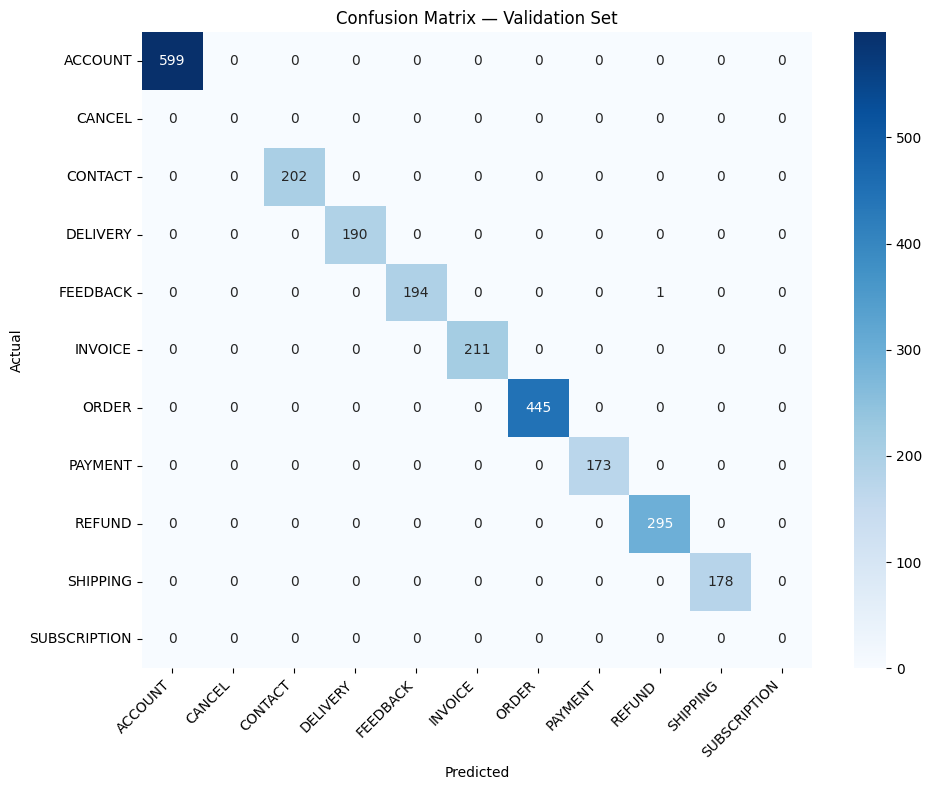

In [50]:
# ========== VISUALIZE RESULTS ==========
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Get predictions on validation set
val_predictions  = trainer.predict(dataset["validation"])
predicted_labels = np.argmax(val_predictions.predictions, axis=1)
true_labels      = val_predictions.label_ids

# Build the label ordering from the model config (safest — stays in sync with training)
# id2label is a dict like {0: 'ACCOUNT', 1: 'CONTACT', ...}
num_labels   = len(model.config.id2label)
label_names  = [model.config.id2label[i] for i in range(num_labels)]

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_labels, predicted_labels, labels=list(range(num_labels)))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title('Confusion Matrix — Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()